# `VoxelIntensity` demo: from matter density to $P(I)$

Demonstrates the full pipeline end to end:

$$P(\delta_m) \xrightarrow{\text{bias + stochasticity}} P(N_t) \xrightarrow{\text{single-source }P(I|1),\text{ Fourier power-sum}} P(I)$$

using `SSLimPy.LIMsurvey.voxel_intensity.VoxelIntensity`, which wires together
`MatterDensityPDF`, `TracerPDF`, and the single-source intensity builder
`build_P_I_given_1`

In [1]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import warnings

from SSLimPy.interface import sslimpy
from SSLimPy.interface import updater
from SSLimPy.LIMsurvey import voxel_intensity

## 1. Cosmology, halo model, `AstroFunctions`

Same setup as the other demo notebooks in this project -- `AstroFunctions`
here is what supplies the luminosity function (`haloluminosityfunction`,
`model_type="ML"` in this example) and the L-to-temperature conversion
(`CLT`) that `build_P_I_given_1` uses.

In [2]:
settings = {
    "code": "class",
    "nonlinearMatpow": True,
    "output": [],
    "kmin": 1e-4 * u.Mpc**-1,
    "kmax": 300 * u.Mpc**-1,
    "nk": 400,
}
cosmodict = {
    "h": 0.70,
    "Omegam": 0.3,
    "As": 2.1e-9,
    "Omegab": 0.05,
}

myssl = sslimpy.SSLimPy(settings_dict=settings, cosmopars=cosmodict)

halo_dict = {
    "hmf_model": "Tinker",
    "bias_model": "Tinker05",
    "halo_tracer": "matter",
    # Rmin subido de 0.0001 a 0.65 Mpc para que Mmin salga ~4.7e10 Msun,
    # en vez del suelo fijo de 1e9 Msun que trae halo_model.py por defecto.
    # Con Mmin=1e9, N_bar salía dominado por halos de masa tan baja que la
    # extrapolacion de SilvaCII ahi no es de fiar (N_bar=2242, separacion
    # media ~1 Mpc); con Mmin~4.7e10 (mas cerca del corte de Vos-Gines para
    # HI, ~4.5e10) sale N_bar=68, mucho mas razonable para emisores de
    # linea.
    "Rmin": 0.65 * u.Mpc,
}

myhalo = updater.update_halomodel(myssl.current_halomodel, cosmodict, halo_dict, myssl.cfg)

survey_dict = {
    "Tsys_NEFD": 40 * u.uK, "Nfeeds": 19, "tobs": 1300 * u.h, "nD": 1,
    "beam_FWHM": 4.0 * u.arcmin, "nu": 1.897 * u.THz, "dnu": 900 * u.MHz,
    "nuObs": 250 * u.GHz, "Delta_nu": 50 * u.GHz, "Omega_field": 140 * u.deg**2,
}
astrodict_CII = {
    "model_type": "ML", "model_name": "SilvaCII",
    "model_par": {"a": 0.8475, "b": 7.2203, "SFR_file": "sfr_release.dat", "do_quench": False},
    "sigma_scatter": 0.37, "meanperserve_scatter": True,
}
myastro = updater.update_astro(
    myssl.current_astro, cosmodict, halo_dict, astrodict_CII, survey_dict, myssl.cfg
)

R0, z0 = 8.0 * u.Mpc, 0.5

  █████   █████  █       █            █████   █    █ 
 █     █ █     █ █            █   █   █    █  █   █  
 █       █       █     ███   █ █ █ █  █    █   █ █   
  █████   █████  █       █   █  █  █  █████     █    
       █       █ █       █   █     █  █        █     
 █     █ █     █ █       █   █     █  █       █      
  █████   █████  █████ █████ █     █  █      █       

#---------------------------------------------------#


/home/chema/miniconda3/envs/lim/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/chema/postdoc/LIM/src/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:166: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


## 2. Build `VoxelIntensity`

One instance per tracer sample; `bias_params` is forwarded to `TracerPDF`
(everything it accepts except `matter_pdf`/`N_bar`, which `VoxelIntensity`
supplies itself -- `N_bar` comes from integrating `myastro`'s own
luminosity function, so it is automatically consistent between $P(N_t)$
and $P(I|1)$; see `_luminosity_moments()`'s docstring).

In [3]:
vid = voxel_intensity.VoxelIntensity(
    myastro,
    vid_params={
        "bias_params": {
            "b1_G": 1.5, "b2_G": 0.3,
            # bias_model="gaussian_lagrangian" (the default) is left as-is
        },
    },
)

_, _, _, N_bar_check = voxel_intensity._luminosity_moments(myastro, z0, R0)
print(f"N_bar (from the luminosity function, R={R0}, z={z0}): {N_bar_check:.4g}")

N_bar (from the luminosity function, R=8.0 Mpc, z=0.5): 67.87


## 3. $P(N_t)$: the emitter-count PDF

Delegates to `TracerPDF.marginal_pmf` (the CosMomentum-validated discrete
route).

N_max = 4000, sum(P) = 1.0001  (should be ~1)


(-1.0, 400.0)

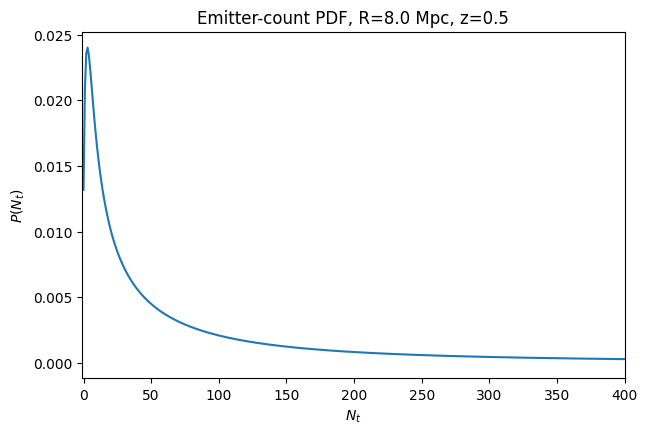

In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    N_grid, P_N = vid.emitter_number_pdf(R0, z0, N_max='auto')

print(f"N_max = {N_grid.max():.0f}, sum(P) = {np.sum(P_N):.4f}  (should be ~1)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(N_grid, P_N, "-")
ax.set_xlabel(r"$N_t$"); ax.set_ylabel(r"$P(N_t)$")
ax.set_title(f"Emitter-count PDF, R={R0}, z={z0}")

ax.set_xlim(-1, 400)

## 4. $P(I\mid 1)$: the single-source intensity PDF

From `myastro`'s own luminosity function -- see `build_P_I_given_1`'s
docstring for the $L\to I$ conversion and the `CLT`/volume subtlety.

N_bar = 67.87
integral of P(I|1) dI = 1.0000  (should be ~1)


(1e-05, 100000.0)

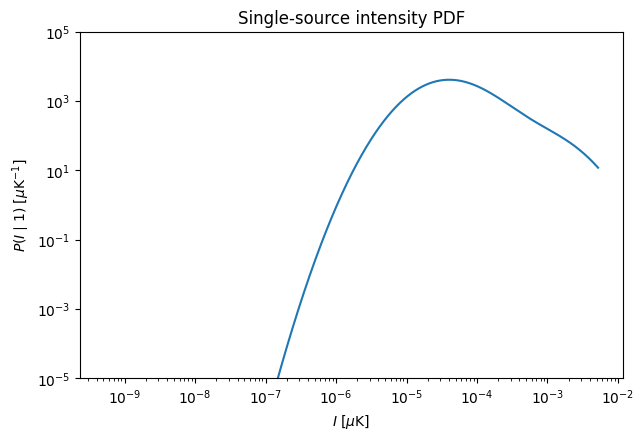

In [19]:
I1_grid, P_I1, N_bar = voxel_intensity.build_P_I_given_1(myastro, z0, R0)

print(f"N_bar = {N_bar:.4g}")
print(f"integral of P(I|1) dI = {np.trapezoid(P_I1.to(1/u.uK).value, I1_grid.to(u.uK).value):.4f}  (should be ~1)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(I1_grid.to(u.uK).value, P_I1.to(1/u.uK).value, "-")
ax.set_xlabel(r"$I$ [$\mu$K]"); ax.set_ylabel(r"$P(I\mid 1)$ [$\mu$K$^{-1}$]")
ax.set_title("Single-source intensity PDF")

ax.set_ylim(1e-5, 1e5)